# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Setup](#setup)
2. [Dataset Overview](#dataset-overview)
3. [Handling Missing Values](#handling-missing-values)
4. [Feature Distributions](#feature-distributions)
5. [Possible Biases](#possible-biases)
6. [Correlations](#correlations)

## 1. Setup <a id='setup'></a>

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from shapely.geometry import Polygon

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# Paths to the three dataset splits
DATA_ROOT = Path('../Data')
TRAIN_DIR = DATA_ROOT / 'extracted_data_train_patch_normalized'
TEST_DIR  = DATA_ROOT / 'extracted_data_2aux_test_v4_centroids_all_classes_final'
VAL_DIR   = DATA_ROOT / 'extracted_data_2aux_v4_cleaned_centroid_raw'

SPLITS = {'train': TRAIN_DIR, 'test': TEST_DIR, 'val': VAL_DIR}

for name, path in SPLITS.items():
    print(f'{name:6s}: {path.exists()} — {path}')

train : True — ../Data/extracted_data_train_patch_normalized
test  : True — ../Data/extracted_data_2aux_test_v4_centroids_all_classes_final
val   : True — ../Data/extracted_data_2aux_v4_cleaned_centroid_raw


## 2. Dataset Overview <a id='dataset-overview'></a>

In [2]:
records = []

for split, folder in SPLITS.items():
    # Use red channel images as anchors — one file per sample, all channels share the same index
    red_files = sorted(folder.glob('red_*.png'))

    for red_path in tqdm(red_files, desc=split):
        # Extract the numeric sample index from the filename (e.g. 'red_0.png' -> '0')
        idx = red_path.stem.split('_')[1]
        record = {'split': split, 'idx': idx}

        # Read image dimensions — identical across all channels of the same sample
        img = Image.open(red_path)
        record['width'], record['height'] = img.size

        # Count annotated tree crowns — the JSON stores each crown as a polygon under key 'Trees'
        ann_path = folder / f'annotation_{idx}.json'
        if ann_path.exists():
            with open(ann_path) as f:
                ann = json.load(f)
            record['tree_count'] = len(ann.get('Trees', []))
        else:
            record['tree_count'] = None

        records.append(record)

df = pd.DataFrame(records)

# Build a flat list of all (split, folder, idx) tuples for later reuse
all_samples = [(split, folder, red_path.stem.split('_')[1])
               for split, folder in SPLITS.items()
               for red_path in sorted(folder.glob('red_*.png'))]

print(f'Total samples : {len(df)}')
print(df.groupby('split')['idx'].count().rename('samples'))
print(f'\nImage size    : {df["width"].unique()[0]} x {df["height"].unique()[0]} px')
print(f'Trees total   : {df["tree_count"].sum():.0f}')
print(f'Trees/image   : min={df["tree_count"].min():.0f}  mean={df["tree_count"].mean():.1f}  max={df["tree_count"].max():.0f}')

val: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 74/74 [00:00<00:00, 378.90it/s]

Total samples : 183
split
test     25
train    84
val      74
Name: samples, dtype: int64

Image size    : 1000 x 1014 px
Trees total   : 51740
Trees/image   : min=0  mean=282.7  max=1779


**Results:** The dataset contains 183 samples in total — 84 training, 25 test, and 74 validation images — each at 1000 × 1014 px. Across all images, 51,740 individual tree crowns are annotated. The mean tree count per image is 282.7, but the range from 0 to 1,779 indicates high variation between open fields and dense forests.

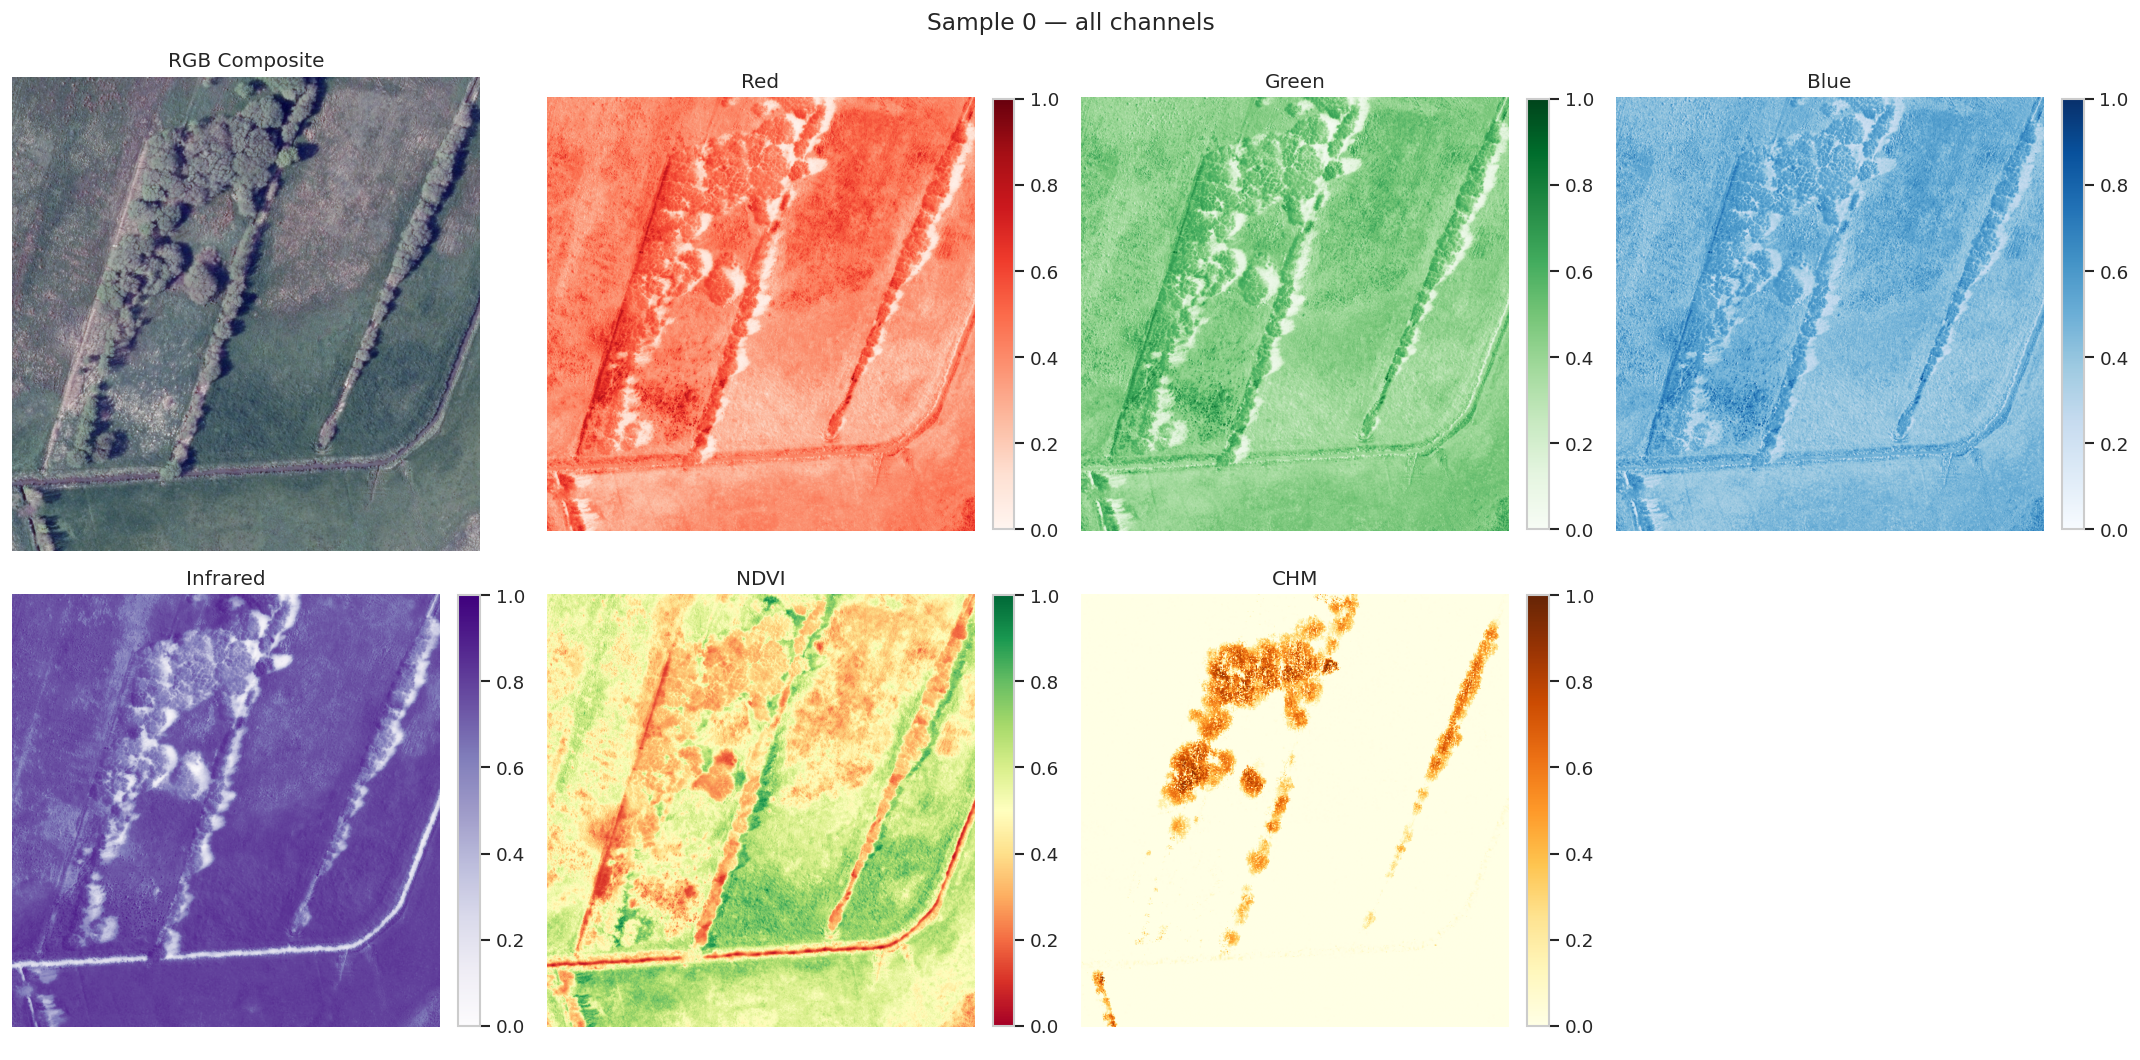

In [3]:
# Load all six channels for one representative training sample
sample_idx = '0'
sample_dir = TRAIN_DIR

channels = {
    'Red':      np.array(Image.open(sample_dir / f'red_{sample_idx}.png'),      dtype=float),
    'Green':    np.array(Image.open(sample_dir / f'green_{sample_idx}.png'),    dtype=float),
    'Blue':     np.array(Image.open(sample_dir / f'blue_{sample_idx}.png'),     dtype=float),
    'Infrared': np.array(Image.open(sample_dir / f'infrared_{sample_idx}.png'), dtype=float),
    'NDVI':     np.array(Image.open(sample_dir / f'ndvi_{sample_idx}.png'),     dtype=float),
    'CHM':      np.array(Image.open(sample_dir / f'chm_{sample_idx}.png'),      dtype=float),
}

def normalize_for_display(arr):
    """
    Min-max scale array to [0, 1] for imshow.
    Required because the training folder contains z-score normalised data
    (pixel values roughly in [-5, +6] rather than the standard 0–255 range).
    """
    lo, hi = arr.min(), arr.max()
    if hi == lo:
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)

# Stack the three visible channels into an (H, W, 3) float array for the RGB composite
rgb = np.stack([
    normalize_for_display(channels['Red']),
    normalize_for_display(channels['Green']),
    normalize_for_display(channels['Blue']),
], axis=-1)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f'Sample {sample_idx} — all channels', fontsize=14)

axes[0, 0].imshow(rgb)
axes[0, 0].set_title('RGB Composite')
axes[0, 0].axis('off')

# Each channel gets a semantically meaningful colormap:
# vegetation indices in green/red, height in brown, visible bands in their own colour
cmaps = ['Reds', 'Greens', 'Blues', 'Purples', 'RdYlGn', 'YlOrBr']
for ax, (name, arr), cmap in zip(axes.flat[1:], channels.items(), cmaps):
    im = ax.imshow(normalize_for_display(arr), cmap=cmap)
    ax.set_title(name)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[1, 3].axis('off')
plt.tight_layout()
plt.show()

**Results:** The CHM channel clearly highlights tree clusters as bright regions against a flat background, confirming that height data is a strong spatial cue for tree detection. The NDVI channel shows elevated values (warmer colours) over vegetated areas. The visible RGB channels look perceptually distorted because each channel is normalised independently — the relative brightness relationships that define natural colour are lost. This is expected for pre-processed training data.

## 3. Handling Missing Values <a id='handling-missing-values'></a>

For image datasets, missing values mean: missing files per sample, or invalid pixel values (NaN) in float channels like NDVI and CHM.

In [4]:
# Expected files for each sample — boundary only exists in train and val
EXPECTED_ALL    = ['red', 'green', 'blue', 'infrared', 'ndvi', 'chm', 'annotation']
EXPECTED_TRAIN  = EXPECTED_ALL + ['boundary']

missing_report = []

for split, folder in SPLITS.items():
    expected = EXPECTED_TRAIN if split in ('train', 'val') else EXPECTED_ALL
    red_files = sorted(folder.glob('red_*.png'))
  
    for red_path in red_files:
        idx = red_path.stem.split('_')[1]

        for channel in expected:
            # annotation has both .png and .json
            if channel == 'annotation':
                for ext in ['png', 'json']:
                    path = folder / f'{channel}_{idx}.{ext}'
                    if not path.exists():
                        missing_report.append({'split': split, 'idx': idx, 'missing': f'{channel}.{ext}'})
            else:
                path = folder / f'{channel}_{idx}.png'
                if not path.exists():
                    missing_report.append({'split': split, 'idx': idx, 'missing': f'{channel}.png'})

if missing_report:
    print(f'Missing files found: {len(missing_report)}')
    print(pd.DataFrame(missing_report))
else:
    print('No missing files — all expected files present for every sample.')

No missing files — all expected files present for every sample.


**Results:** All expected files are present for every sample across all three splits. No data loading errors will occur due to missing inputs.

In [5]:
import random
random.seed(42)

# Scan a random subset of 20 samples across all splits for NaN pixels
# (full scan over 183 images would work too but this is faster)
all_samples = [(split, folder, red_path.stem.split('_')[1])
               for split, folder in SPLITS.items()
               for red_path in sorted(folder.glob('red_*.png'))]

subset = random.sample(all_samples, min(20, len(all_samples)))
nan_found = False

for split, folder, idx in subset:
    for channel in ['ndvi', 'chm']:
        arr = np.array(Image.open(folder / f'{channel}_{idx}.png'), dtype=float)
        n_nan = np.isnan(arr).sum()
        if n_nan > 0:
            print(f'NaN pixels in {split} / {channel}_{idx}: {n_nan}')
            nan_found = True

if not nan_found:
    print('No NaN pixels found in NDVI and CHM channels (sample of 20 images).')

No NaN pixels found in NDVI and CHM channels (sample of 20 images).


**Results:** No NaN values were detected in the NDVI or CHM channels across the sampled images. The dataset is clean and requires no imputation or pixel-level masking before training.

## 4. Feature Distributions <a id='feature-distributions'></a>

In [6]:
random.seed(42)
N_IMAGES       = 30
PIXELS_PER_IMG = 5000
CHANNELS       = ['red', 'green', 'blue', 'infrared', 'ndvi', 'chm']

pixel_samples = {ch: [] for ch in CHANNELS}
sample_subset = random.sample(all_samples, min(N_IMAGES, len(all_samples)))

for split, folder, idx in tqdm(sample_subset, desc='Sampling pixels'):
    for ch in CHANNELS:
        arr = np.array(Image.open(folder / f'{ch}_{idx}.png'), dtype=float).flatten()
        # replace=True handles edge cases where an image has fewer pixels than PIXELS_PER_IMG
        n = min(PIXELS_PER_IMG, len(arr))
        chosen = np.random.choice(arr, size=n, replace=True)
        pixel_samples[ch].extend(chosen.tolist())

print(f'Sampled {N_IMAGES} images — {len(pixel_samples["red"]):,} values per channel')

Sampling pixels: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:03<00:00,  7.83it/s]

Sampled 30 images — 150,000 values per channel


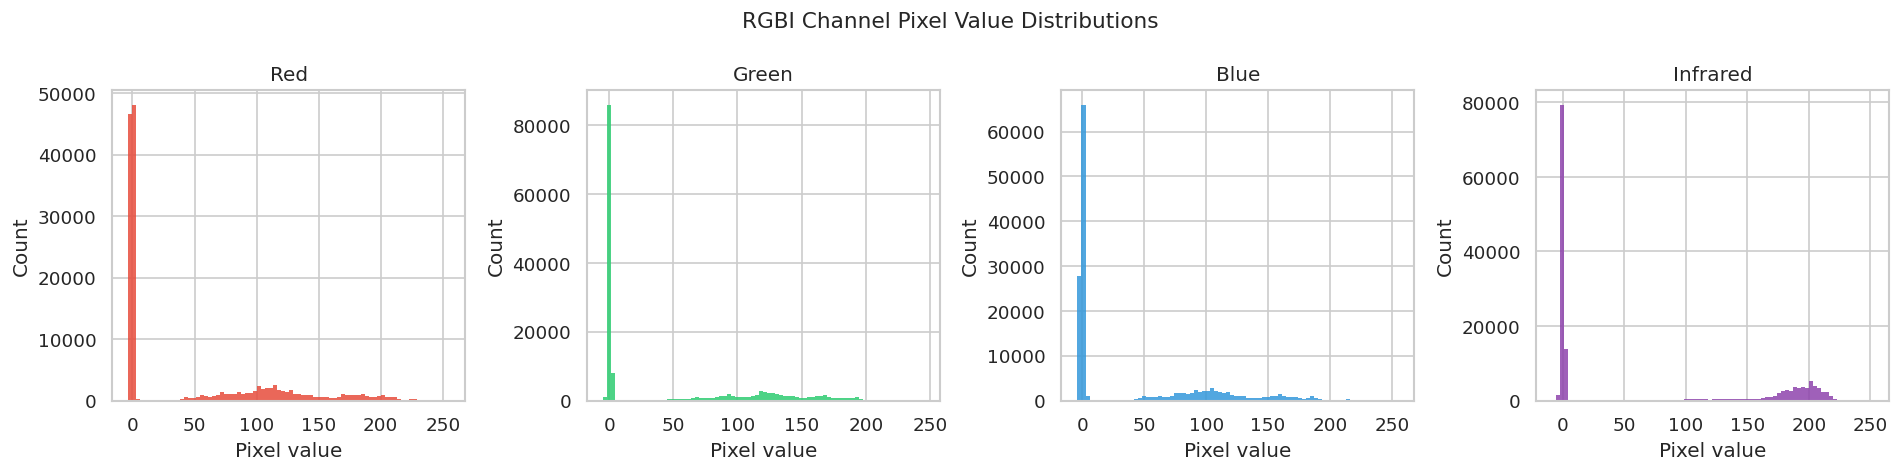

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('RGBI Channel Pixel Value Distributions', fontsize=13)

channel_styles = [
    ('red',      'Red',      '#e74c3c'),
    ('green',    'Green',    '#2ecc71'),
    ('blue',     'Blue',     '#3498db'),
    ('infrared', 'Infrared', '#8e44ad'),
]

for ax, (ch, label, color) in zip(axes, channel_styles):
    ax.hist(pixel_samples[ch], bins=80, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(label)
    ax.set_xlabel('Pixel value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

**Results:** The visible channels (Red, Green, Blue) show right-skewed distributions concentrated at lower values, reflecting that large portions of the images are dark (fields, roads, bare soil). The Infrared channel shows a bimodal distribution — one peak for non-vegetated surfaces and a second peak at higher values from vegetation, which reflects strongly in the near-infrared spectrum. This bimodal structure is why the infrared channel is particularly informative for separating trees from background.

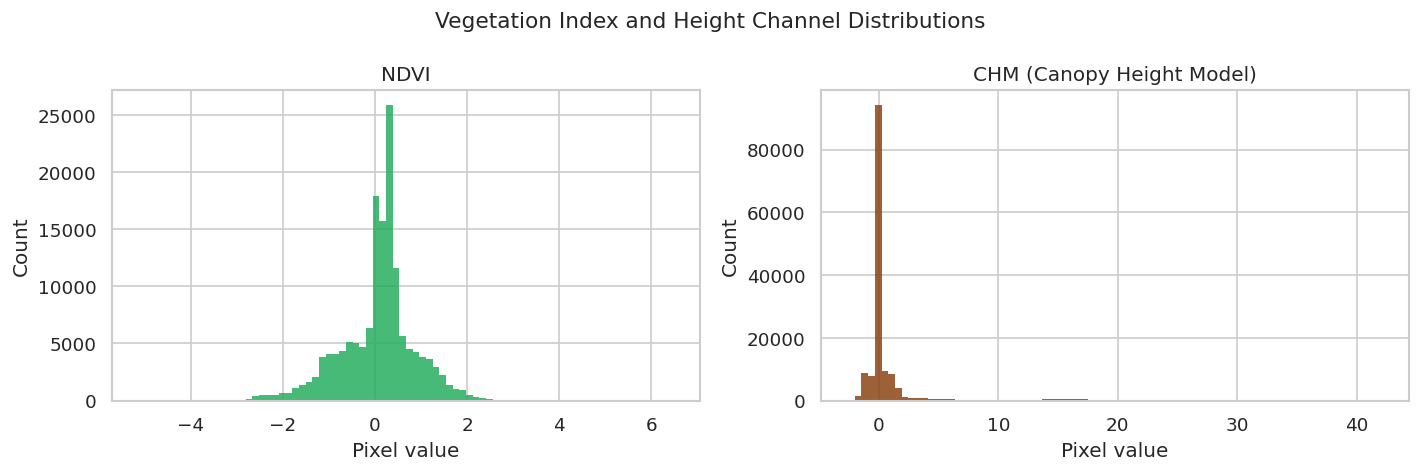

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Vegetation Index and Height Channel Distributions', fontsize=13)

axes[0].hist(pixel_samples['ndvi'], bins=80, color='#27ae60', alpha=0.85, edgecolor='none')
axes[0].set_title('NDVI')
axes[0].set_xlabel('Pixel value')
axes[0].set_ylabel('Count')

axes[1].hist(pixel_samples['chm'], bins=80, color='#8B4513', alpha=0.85, edgecolor='none')
axes[1].set_title('CHM (Canopy Height Model)')
axes[1].set_xlabel('Pixel value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Results:** The NDVI distribution is centred near zero with a slight right skew — consistent with z-score normalisation applied during preprocessing. The long right tail represents pixels with high vegetation density (dense canopy). The CHM distribution is strongly right-skewed with a large spike near zero (flat ground, fields, roads) and a sparse tail extending to ~45 (tall trees and buildings). The majority of pixels in the dataset represent ground-level surfaces, confirming that annotated tree crowns occupy only a minority of the total image area.

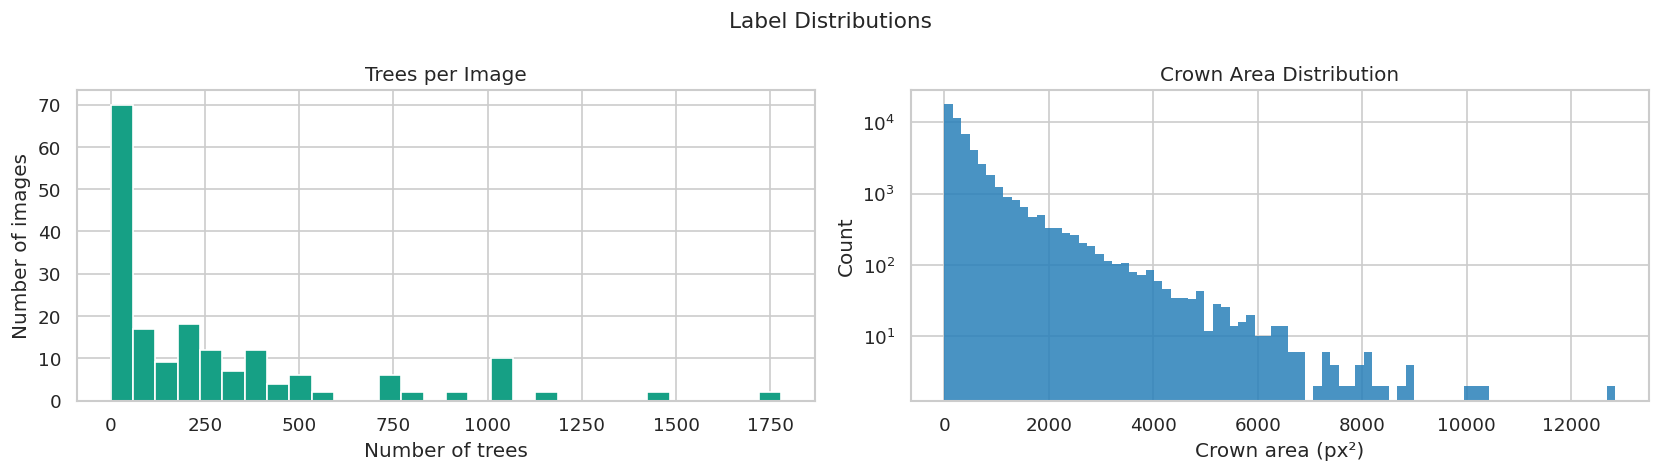

Total crowns    : 51,740
Median area     : 263 px²
Mean area       : 526 px²
Max area        : 12844 px²


In [9]:
from shapely.geometry import Polygon

crown_areas = []

for split, folder in SPLITS.items():
    for red_path in sorted(folder.glob('red_*.png')):
        idx = red_path.stem.split('_')[1]
        ann_path = folder / f'annotation_{idx}.json'
        if ann_path.exists():
            with open(ann_path) as f:
                ann = json.load(f)
            for polygon_coords in ann.get('Trees', []):
                if len(polygon_coords) >= 3:
                    try:
                        area = Polygon(polygon_coords).area
                        crown_areas.append(area)
                    except Exception:
                        pass

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Label Distributions', fontsize=13)

# Tree count per image
axes[0].hist(df['tree_count'].dropna(), bins=30, color='#16a085', edgecolor='white')
axes[0].set_title('Trees per Image')
axes[0].set_xlabel('Number of trees')
axes[0].set_ylabel('Number of images')

# Crown area distribution (log scale for readability)
axes[1].hist(crown_areas, bins=80, color='#2980b9', edgecolor='none', alpha=0.85)
axes[1].set_title('Crown Area Distribution')
axes[1].set_xlabel('Crown area (px²)')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f'Total crowns    : {len(crown_areas):,}')
print(f'Median area     : {np.median(crown_areas):.0f} px²')
print(f'Mean area       : {np.mean(crown_areas):.0f} px²')
print(f'Max area        : {np.max(crown_areas):.0f} px²')

**Results:** The tree count distribution is heavily right-skewed — most images contain fewer than 250 trees (open or suburban landscapes), while a small number of images contain over 1,000 trees (dense forest patches). The crown area distribution (log scale) confirms that small crowns dominate: the median crown covers 263 px², equivalent to roughly 10.5 m² at 20 cm resolution (~3.6 m diameter). The mean of 526 px² is pulled upward by a small number of very large crowns (max 12,844 px²), indicating that large trees are rare but present.

## 5. Possible Biases <a id='possible-biases'></a>

Several biases in this dataset could limit model generalisation to Kiel:

**Geographic / Species Bias:** All images originate from Denmark. Tree species composition, urban structure, and canopy density may differ from Kiel, Germany.

**Seasonal Bias:** Imagery was captured during the growing season (leaf-on). Performance on autumn or winter imagery will be reduced.

**Resolution Bias:** The Denmark dataset uses 20 cm resolution. The Kiel prediction data includes 7 cm tiles (DOP7), requiring fine-tuning to adapt.

**Domain Shift (Kiel vs. Denmark):** A quantitative comparison is not yet possible — access to Kiel data is pending an NDA with Landeshauptstadt Kiel. Once available, a comparative analysis of NDVI distributions and pixel statistics will be added.

The following plot shows tree density variation across images, which reflects the range of landscape types (dense forest to open fields) covered by the dataset.

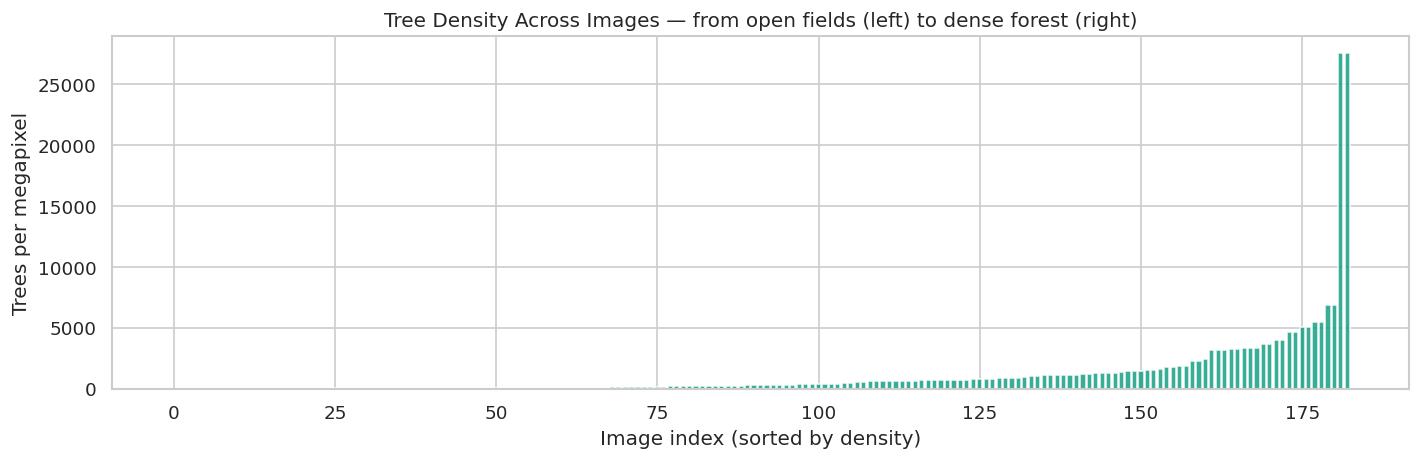

       count    mean     std   min   25%    50%     75%      max
split                                                           
test    25.0   917.1   944.5  39.9  83.6  761.3  1274.0   3353.7
train   84.0  1121.1  3236.4   0.0  13.8  187.8   841.5  27565.2
val     74.0  1272.5  3422.5   0.0  27.2  304.8  1060.3  27565.2


In [10]:
# Tree density = trees per megapixel, shows landscape type variation across images
df['tree_density'] = df['tree_count'] / (df['width'] * df['height']) * 1e6

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(df)), df['tree_density'].sort_values().values, color='#16a085', alpha=0.85)
ax.set_xlabel('Image index (sorted by density)')
ax.set_ylabel('Trees per megapixel')
ax.set_title('Tree Density Across Images — from open fields (left) to dense forest (right)')
plt.tight_layout()
plt.show()

print(df.groupby('split')['tree_density'].describe().round(1))

**Results:** Tree density varies dramatically across the dataset — roughly the bottom half of images (sorted by density) contain near-zero trees, while the top quarter are densely forested. Comparing splits: the test set has a minimum density of 39.9 trees/megapixel and no truly empty images, while both train and val include images with zero annotated trees. This means the test split is biased towards vegetated scenes and does not evaluate model performance on open, tree-free landscapes.

## 6. Correlations <a id='correlations'></a>

We compute per-image mean values for each channel and correlate them with tree count to understand which features are most informative for tree detection.

Computing means: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 183/183 [00:11<00:00, 16.33it/s]


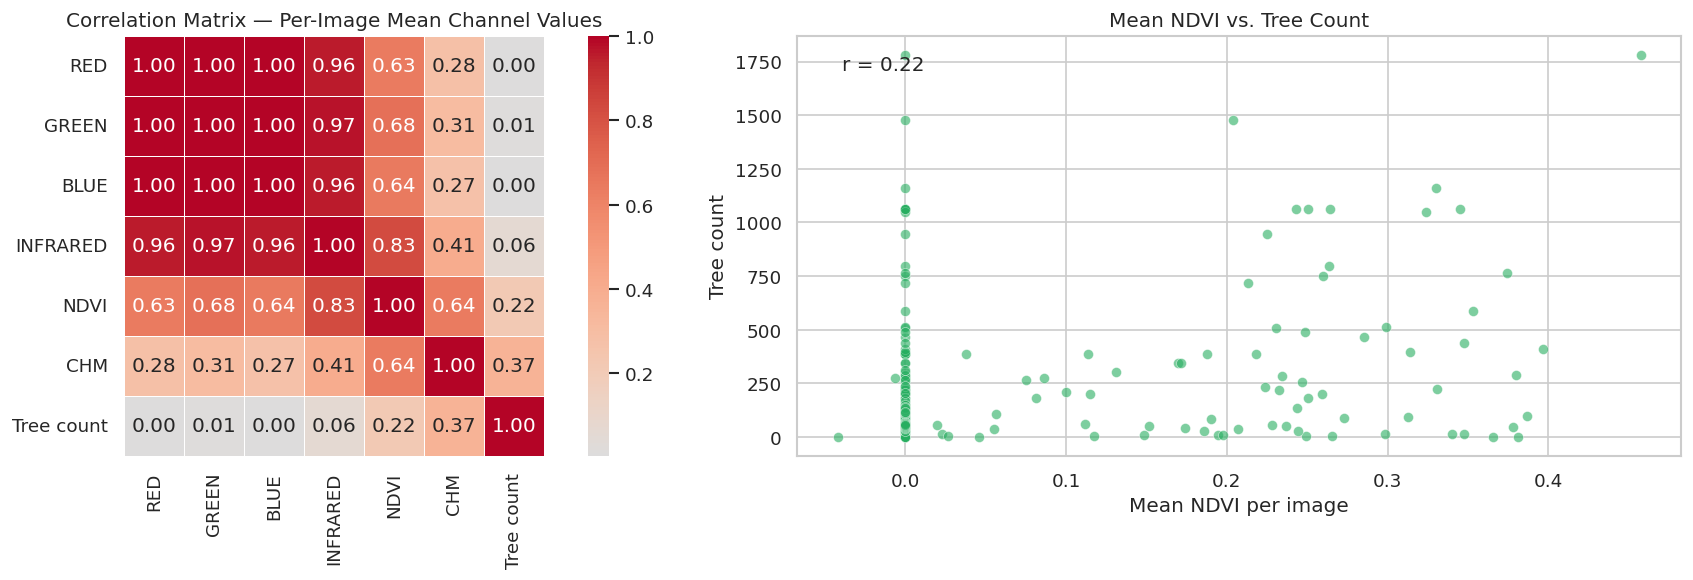

In [11]:
# Compute per-image mean for each channel across all samples
per_image = []

for split, folder, idx in tqdm(all_samples, desc='Computing means'):
    row = {'split': split, 'idx': idx}
    for ch in CHANNELS:
        arr = np.array(Image.open(folder / f'{ch}_{idx}.png'), dtype=float)
        row[f'mean_{ch}'] = arr.mean()
    per_image.append(row)

stats_df = pd.DataFrame(per_image)

# Merge tree count from df
stats_df = stats_df.merge(df[['split', 'idx', 'tree_count']], on=['split', 'idx'], how='left')

# Correlation matrix
mean_cols = [f'mean_{ch}' for ch in CHANNELS] + ['tree_count']
corr = stats_df[mean_cols].corr()
corr.index   = [c.replace('mean_', '').upper() if c != 'tree_count' else 'Tree count' for c in corr.index]
corr.columns = corr.index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Matrix — Per-Image Mean Channel Values')

# Scatter: mean NDVI vs. tree count
axes[1].scatter(stats_df['mean_ndvi'], stats_df['tree_count'],
                alpha=0.6, color='#27ae60', edgecolors='white', linewidth=0.4)
axes[1].set_xlabel('Mean NDVI per image')
axes[1].set_ylabel('Tree count')
axes[1].set_title('Mean NDVI vs. Tree Count')

r = stats_df[['mean_ndvi', 'tree_count']].corr().iloc[0, 1]
axes[1].annotate(f'r = {r:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=12)

plt.tight_layout()
plt.show()

**Results:** The RGB channels are almost perfectly correlated with each other (r ≈ 1.00), meaning they carry largely redundant information at the image level. Infrared correlates strongly with RGB (r ≈ 0.96) but adds unique signal through its high correlation with NDVI (r = 0.83). CHM is the strongest single predictor of tree count (r = 0.37), confirming that height information is the most direct indicator of tree presence. NDVI shows a weaker but meaningful correlation with tree count (r = 0.22). The visible RGB channels alone have near-zero correlation with tree count (r ≈ 0.00), which demonstrates that colour information alone is insufficient for tree detection and justifies using all six input channels (RGBI + NDVI + CHM).